#  LINEAR REGRESSION

The model makes a prediction by simply computing a weighted sum of the input features, plus a constant called the bias term (also called intercept term)

## Equation 1: Linear Regression Model Prediction

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

In this equation:

- $\hat{y}$ is the predicted value.
- $n$ is the number of features.
- $x_i$ is the $i^{th}$ feature value.
- $\theta_j$ is the $j^{th}$ model parameter (including the bias term $\theta_0$ and the feature weights $\theta_1, \theta_2, \ldots, \theta_n$).

### Equation 2: Linear Regression Model Prediction
$$\hat{y} = h_{\theta}\mathbf{x} = \theta \cdot \mathbf{x}$$

In this equation:

- **θ** is the model's **parameter vector**, containing the bias term $\theta_0$ and the feature weights $\theta_1$ to $\theta_n$.
- **x** is the instance's **feature vector**, containing $x_0$ to \x_n, with $x_0$ always equal to 1.
- **θ · x** is the dot product of the vectors **θ** and **x**, which is equal to:   $\theta_0x_0 + \theta_1x_1 + \theta_2x_2 + \cdots + \theta_nx_n$


- $h_{\theta}$ is the hypothesis function, using the model parameters **θ**.

### Equation 3. MSE Cost Function for a Linear Regression Model

$
\text{MSE}(\mathbf{X}, h_{\theta}) =
\frac{1}{m}
\sum_{i=1}^{m}
\left(\theta^T \mathbf{x}^{i} - y^{i}\right)^2
$

The MSE of a Linear Regression hypothesis $h_{\theta}$ on a training set $\mathbf{X}$ is calculated using the above equation.

Where:

- $m$ is the number of instances in the training set.
- $\mathbf{X}$ is the training set.
- $\mathbf{x}^{i}$ is the feature vector of the $i^{th}$ training instance.
- $y^{i}$ is the actual target value of the $i^{th}$ training instance.
- $\theta^T \mathbf{x}^{i}$ is the prediction made by the model for the $i^{th}$ instance.
- $h_{\theta}$ is the hypothesis function parameterized by $\theta$.
- MSE stands for **Mean Squared Error**.

### Normal Equation
To find the value of $\mathbf{\theta}$ that minimises the value of MSE

$$\hat{\mathbf{\theta}} = (\mathbf{X}^{T}\mathbf{X})^{-1}\mathbf{X}^{T}\mathbf{y}$$

In [1]:
import numpy as np

np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

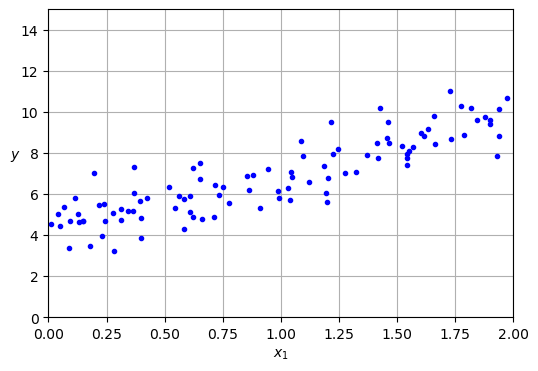

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

Now computing $\hat{\theta}$ using the Normal Equaition.

`Note`: using inv() function from NumPy's linear algebra module (np.linalg) to find inverse of a matrix

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)      #add x0 =1 to each instance
theta_best=np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

The @ operator performs matrix multiplication.\
`Equivalent to:` np.matmul(A,B)

`add_dummy_feature()` is a utility function from scikit-learn that adds a column of 1s to your dataset. \
So that matrix multiplication is possible



THe function to create the data is:

 $y = 4 + 3x_{1} +$ Gaussian noise

In [4]:
theta_best

array([[4.21509616],
       [2.77011339]])

We would have hoped $\theta_0 = 4$ & $\theta_1 = 3$ instead of $\theta_0 = 4.21509616$ & $\theta_1 = 2.77011339$ \
The noise made it impossible to recover the exact parameter. \
The noisier and smaller the dataset is harder it gets.

Now to make prediction using $\hat{\theta}$

In [5]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

#### Plotting the predictions

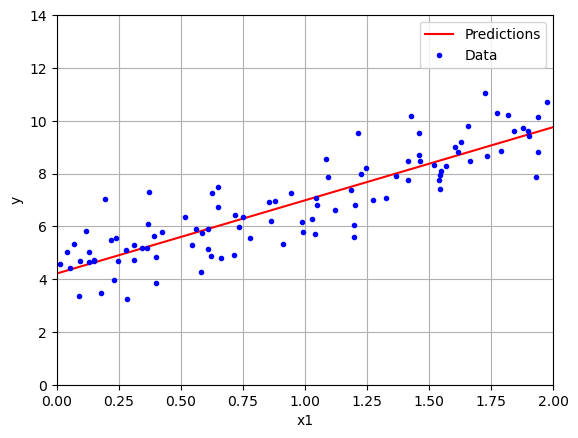

In [6]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Data")
plt.axis([0, 2, 0, 14])
plt.xlabel("x1")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

#### Linear Regression using Sckit Learn is relatively straigthforward

In [7]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [8]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

So basically the previous code was the algorithm of the Linear Regression 